# 02 - Exploratory Data Analysis

## Objective

The goal of this notebook is to explore the cleaned Telco Customer Churn dataset and identify patterns and relationships that may help explain customer churn.

We will investigate:

- Dataset structure
- Target distribution
- Numerical feature distributions
- Categorical feature distributions
- Relationships between features and churn
- Correlations between numerical variables
- Potentially important patterns for machine learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = r"E:\Programming\Practices\Customer churn model\Data\processed\cleaned_telco_customer_churn.csv"

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 20)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [7]:
df.describe(include="object").T

C:\Users\sepri\AppData\Local\Temp\ipykernel_13068\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095
TechSupport,7043,3,No,3473


In [8]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [9]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(22)

In [11]:
duplicates = df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

duplicates

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


In [12]:
duplicate_mask = df.duplicated(keep=False)

duplicate_rows = df.loc[duplicate_mask]

print("Number of rows involved in duplicates:", len(duplicate_rows))
print("Number of duplicate rows excluding first occurrences:", df.duplicated().sum())

Number of rows involved in duplicates: 42
Number of duplicate rows excluding first occurrences: 22


In [13]:
duplicates.groupby(
    list(df.columns.drop("Churn"))
)["Churn"].nunique().value_counts()

Churn
1    20
Name: count, dtype: int64

In [14]:
feature_columns = df.columns.drop("Churn").tolist()

duplicate_groups = (
    df.groupby(feature_columns, dropna=False)["Churn"]
      .agg(["count", "nunique"])
      .query("count > 1")
      .sort_values("count", ascending=False)
)

duplicate_groups

count  \
gender SeniorCitizen Partner Dependents tenure PhoneService MultipleLines InternetService OnlineSecurity      OnlineBackup        DeviceProtection    TechSupport         StreamingTV         StreamingMovies     Contract       PaperlessBilling PaymentMethod    MonthlyCharges TotalCharges          
Male   0             No      No         1      Yes          No            No              No internet service No internet service No internet service No internet service No internet service No internet service Month-to-month No               Mailed check     20.20          20.20             4   
                                                                          Fiber optic     No                  No                  No                  No                  No                  No                  Month-to-month Yes              Electronic check 69.90          69.90             3   
Female 0             No      No         1      Yes          No            No              No internet service No internet service No internet service No internet service No internet service No internet service Month-to-month No               Mailed check     19.65          19.65             3   
                                                                                                                                                                                                                                                                   20.90          20.90             3   
                                                                                                                                                                                                                                                                   19.90          19.90             3   
Male   0             No      No         1      Yes          No            No              No internet service No internet service No internet service No internet service No internet service No internet service Month-to-month No               Mailed check     20.05          20.05             3   
Female 0             No      No         1      Yes          No            DSL             No                  No                  No                  No                  No                  No                  Month-to-month Yes              Mailed check     45.40          45.40             2   
                                                                          Fiber optic     No                  No                  No                  No                  No                  No                  Month-to-month Yes              Electronic check 70.25          70.25             2   
                                                                                                                                                                                                                                 No               Mailed check     71.10          71.10             2   
                                                                          No              No internet service No internet service No internet service No internet service No internet service No internet service Month-to-month No               Mailed check     19.55          19.55             2   
                                                                                                                                                                                                                                                                   19.50          19.50             2   
                                                                                                                                                                                                                                                                   20.40          20.40             2   
                                                                                                                                  

In [15]:
print(
    "Duplicate groups with different Churn labels:",
    (duplicate_groups["nunique"] > 1).sum()
)

Duplicate groups with different Churn labels: 18


In [16]:
conflicting_groups = duplicate_groups[
    duplicate_groups["nunique"] > 1
]

conflicting_groups

count  \
gender SeniorCitizen Partner Dependents tenure PhoneService MultipleLines InternetService OnlineSecurity      OnlineBackup        DeviceProtection    TechSupport         StreamingTV         StreamingMovies     Contract       PaperlessBilling PaymentMethod    MonthlyCharges TotalCharges          
Male   0             No      No         1      Yes          No            No              No internet service No internet service No internet service No internet service No internet service No internet service Month-to-month No               Mailed check     20.20          20.20             4   
                                                                          Fiber optic     No                  No                  No                  No                  No                  No                  Month-to-month Yes              Electronic check 69.90          69.90             3   
Female 0             No      No         1      Yes          No            No              No internet service No internet service No internet service No internet service No internet service No internet service Month-to-month No               Mailed check     19.65          19.65             3   
                                                                                                                                                                                                                                                                   20.90          20.90             3   
                                                                                                                                                                                                                                                                   19.90          19.90             3   
                                                                          DSL             No                  No                  No                  No                  No                  No                  Month-to-month Yes              Mailed check     45.40          45.40             2   
                                                                          Fiber optic     No                  No                  No                  No                  No                  No                  Month-to-month Yes              Electronic check 70.25          70.25             2   
                                                                                                                                                                                                                                 No               Mailed check     71.10          71.10             2   
                                                                          No              No internet service No internet service No internet service No internet service No internet service No internet service Month-to-month No               Mailed check     19.50          19.50             2   
                                                                                                                                                                                                                                                                   20.40          20.40             2   
                                                                                                                                                                                                                                                                   20.50          20.50             2   
                                                                                                                                                                                                                                 Yes              Mailed check     20.25          20.25             2   
Male   0             No      No         1      Yes          No            No              No internet service No internet service 

In [17]:
print(
    "Rows belonging to conflicting feature groups:",
    conflicting_groups["count"].sum()
)

Rows belonging to conflicting feature groups: 42


## Duplicate Feature Combinations

After removing the `customerID` identifier, some customers have identical
values across all remaining features.

These records are not necessarily erroneous duplicates because they may
represent different customers. Furthermore, some identical feature
combinations are associated with different `Churn` labels.

Therefore, these observations are retained in the dataset rather than
being removed as duplicates.

In [18]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

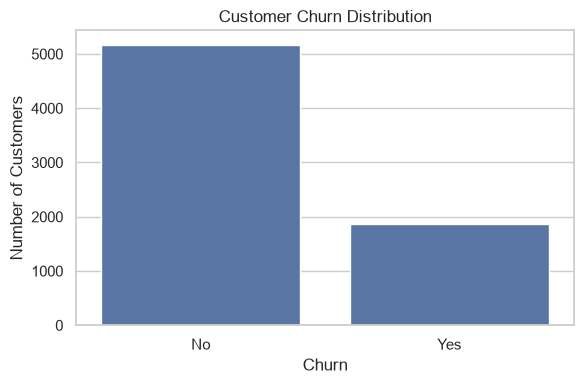

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

داده‌ها با کلاس‌های نامتوازن مواجه‌اند. نسبت کلاس‌ها حدود 73٪ برای No و 27٪ برای Yes است. این نابرابری می‌تواند در آموزش مدل به‌خصوص مدل‌های مبتنی بر فرضیه‌ی کلاس متوازن، مشکل ساز باشد و نیاز به تنظیم وزن کلاس یا نمونه‌گیری متوازن داشته باشد.

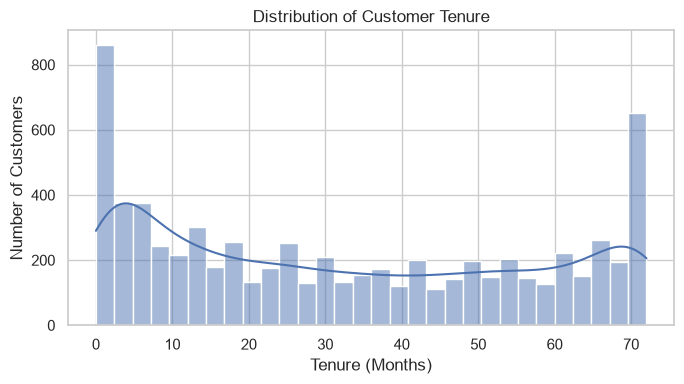

In [21]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Distribution of Customer Tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<div dir="rtl">
در نمودار هیستوگرام با KDE، توزیع tenure یک توزیع نامتقارن و به‌سمت راست کشیده‌شده دارد؛ یعنی اکثر مشتریان دوره‌ی کوتاه‌تر اشتراک دارند و تعداد کمی مشتری با زمان اشتراک طولانی‌تر وجود دارند.<br \> 
تعداد مشتریان با tenure بالا به‌طور تدریجی کاهش می‌یابد.<br \>
این نمودار با جدول آماری گروه‌بندی tenure هماهنگ است: برای گروه No، میانگین tenure حدود 37.57 ماه و میانه 38 ماه است؛ برای گروه Yes، میانگین 17.98 ماه و میانه 10 ماه است. این <b>یعنی churn معمولاً زودتر اتفاق می‌افتد و customer tenure کوتاه‌تر از مشتریان غیر-churn است.<b>

</div>

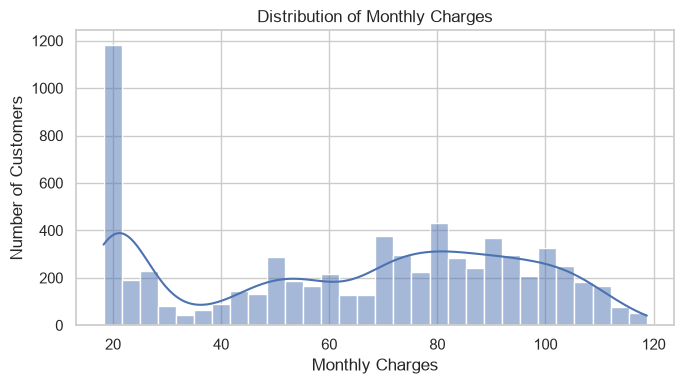

In [22]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Distribution of Monthly Charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<div dir="rtl">
این نتیجه با نمودار Monthly Charges vs Churn هم هماهنگ است: جعبه‌ی Yes به‌طور شفاف ارتفاع بیشتری دارد و میانگین/میانه‌ی بالاتر نشان می‌دهد که هزینه‌های ماهانه در مشتریان churn بالاتر است.
</div>

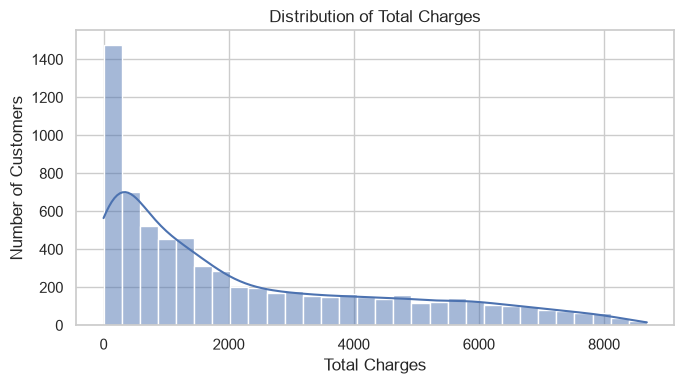

In [23]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="TotalCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Distribution of Total Charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<div dir="rtl">
بیشتر مشتریان مقدار TotalCharges پایین تا متوسط دارند.<br \>
تعداد کمی مشتری هزینه‌ی کل بسیار بالا دارند، که به‌عنوان دم راست توزیع دیده می‌شود.<br \>
توزیع از نظر عددی و بصری نامتقارن است و برای مدل‌های یادگیری، ممکن است نیاز به تبدیل یا scaling داشته باشد.<br \>
<br \>
گروه No هزینه‌ی کل بالاتری دارد؛ یعنی مشتریان حفظ‌شده بیشتر هزینه‌ی کل جمع‌آوری‌شده دارند.<br \>
گروه Yes هزینه‌ی کل پایین‌تر دارد و این به‌خصوص در میانه و میانگین آن دیده می‌شود.<br \>
گروه Yes همچنین پراکندگی کمتری نسبت به No دارد.<br \>
<b>از نظر تئوری، این موضوع کاملاً با tenure کوتاه‌تر گروه Yes سازگار است؛ چون اگر customer مدت کوتاه‌تری در خدمت بوده باشد، هزینه‌ی تجمعی TotalCharges نیز کمتر خواهد بود.<b>
</div>

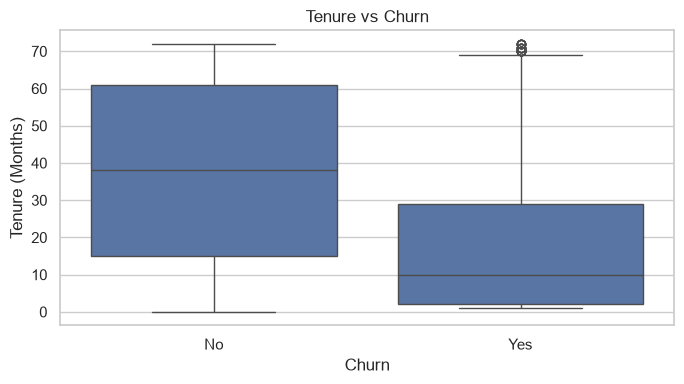

In [24]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Tenure vs Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<div dir="rtl"> 
مشتریان churn نسبت به غیر-churn، زمان اشتراک کوتاه‌تری داشته‌اند.
</div>

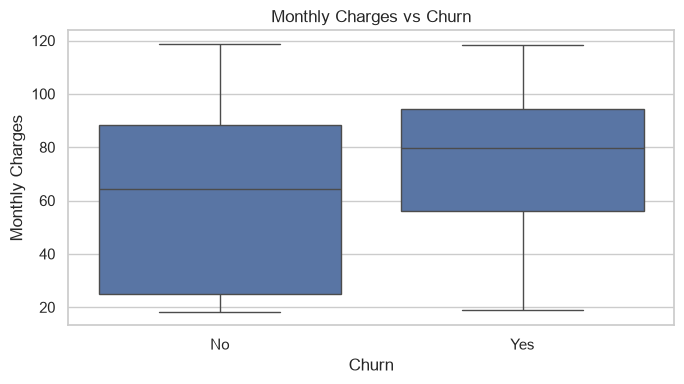

In [25]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Monthly Charges vs Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<div dir="rtl"> 
یعنی هزینه‌ی ماهانه‌ی مشتریان churn در مقایسه با non-churn بیشتر است.<br \>
هزینه‌ی ماهانه می‌تواند به‌عنوان یک قوی‌ترین ویژگی تغییرپذیر در تشخیص churn عمل کند.<br \>
<b>به‌طور کلی، مشتریان با هزینه‌ی ماهانه‌ی بالاتر احتمال بیشتری برای churn دارند.<b>
</div>

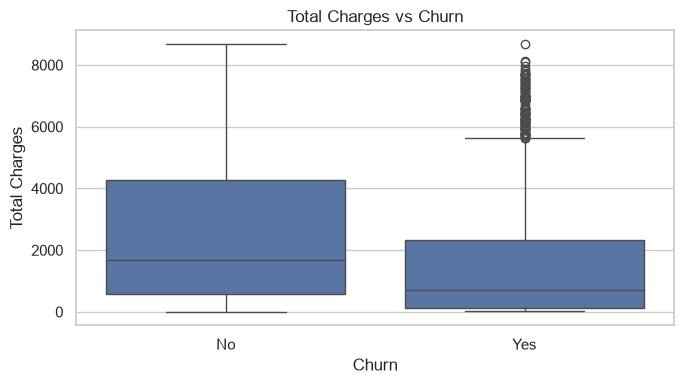

In [26]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Total Charges vs Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### مشتریان churn هزینه کل کمتری دارند.

In [27]:
df.groupby("Churn")["tenure"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
Churn,,,,,
No,37.569965,38.0,24.113777,0,72
Yes,17.979133,10.0,19.531123,1,72


In [28]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
Churn,,,,,
No,61.265124,64.425,31.092648,18.25,118.75
Yes,74.441332,79.650,24.666053,18.85,118.35


In [29]:
df.groupby("Churn")["TotalCharges"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
Churn,,,,,
No,2549.911442,1679.525,2329.954215,0.00,8672.45
Yes,1531.796094,703.550,1890.822994,18.85,8684.80


<div dir="rtl">
<b>نتایج کلی که میتوان گرفت :<b><br \>
churners بیشتر مشتریانی هستند که دارای tenure کوتاه‌تر هستند.<br \>
churners بیشتر مشتریانی هستند که MonthlyCharges بالاتری پرداخت می‌کنند.<br \>
churners معمولاً TotalCharges پایین‌تری دارند؛ چون داده‌شان در زمان کوتاه‌تر و با هزینه‌ی کل کمتر شکل گرفته‌اند.<br \>
داده‌ها در مسئله‌ی churn، اشکال کلاس‌نامتوازن و توزیع‌های کشیده دارند که برای مدل‌های یادگیری باید به‌صورت مناسب مدیریت شوند.<br \>
</div>

In [35]:
categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

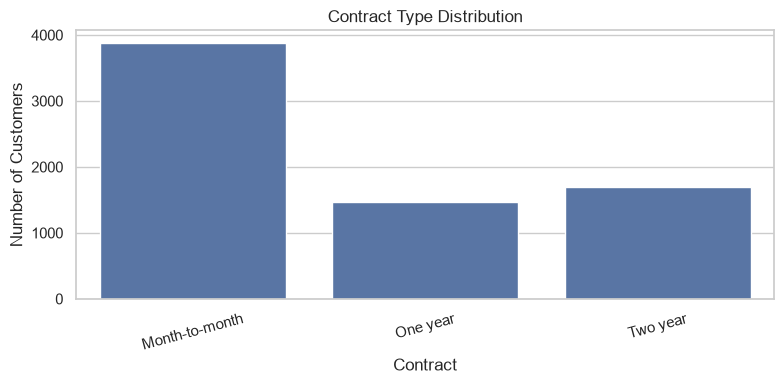

In [31]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="Contract"
)

plt.title("Contract Type Distribution")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../reports/figures/Contract Type Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<div dir="rtl">
به ما می گوید در هر نوع از قرارداد چند درصد از مشتریان churn کرده اند.
</div>

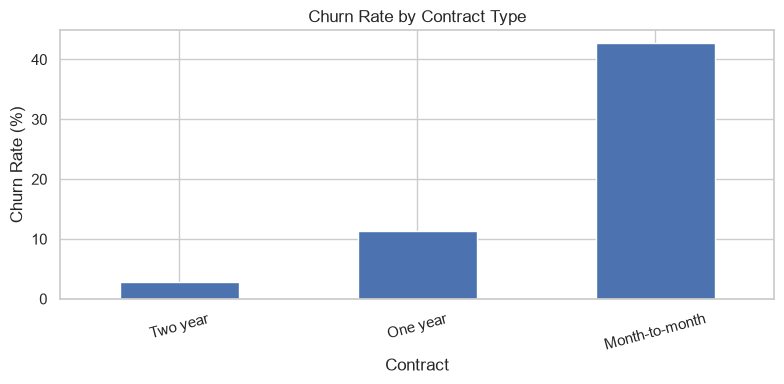

In [33]:
contract_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "../reports/figures/Churn Rate by Contract Type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
def calculate_churn_rate(df, feature):
    return (
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        )["Yes"] * 100
    ).sort_values(ascending=False)

In [36]:
for feature in categorical_features:
    print(f"\n===== {feature} =====")
    print(calculate_churn_rate(df, feature))


===== gender =====
gender
Female    26.920872
Male      26.160338
Name: Yes, dtype: float64

===== Partner =====
Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

===== Dependents =====
Dependents
No     31.279140
Yes    15.450237
Name: Yes, dtype: float64

===== PhoneService =====
PhoneService
Yes    26.709637
No     24.926686
Name: Yes, dtype: float64

===== MultipleLines =====
MultipleLines
Yes                 28.609896
No                  25.044248
No phone service    24.926686
Name: Yes, dtype: float64

===== InternetService =====
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

===== OnlineSecurity =====
OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Yes, dtype: float64

===== OnlineBackup =====
OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Yes, dtyp

In [38]:
numerical_df = df.select_dtypes(
    include=np.number
)

In [39]:
correlation_matrix = numerical_df.corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


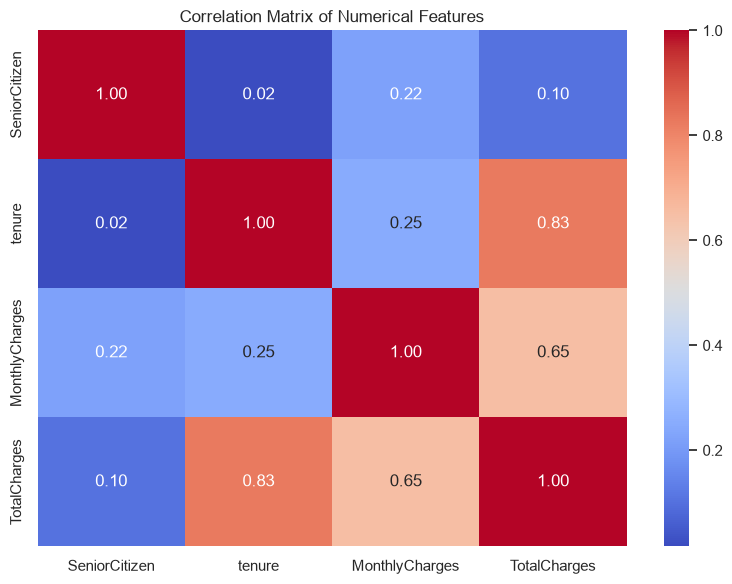

In [41]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Correlation Matrix of Numerical Features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

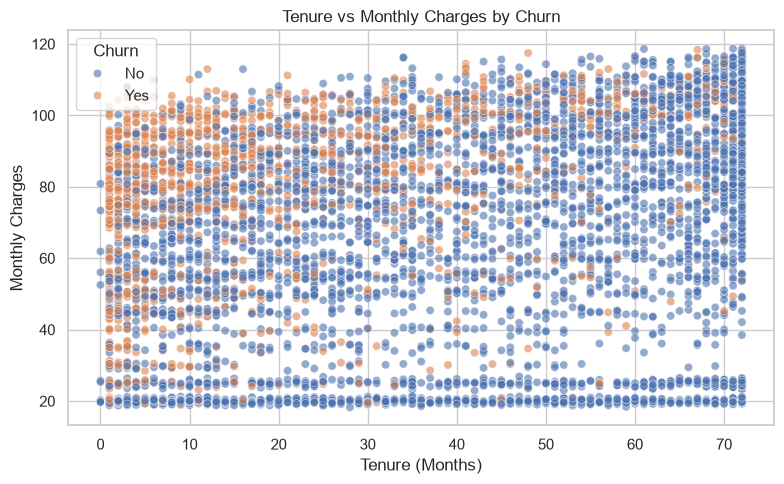

In [42]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

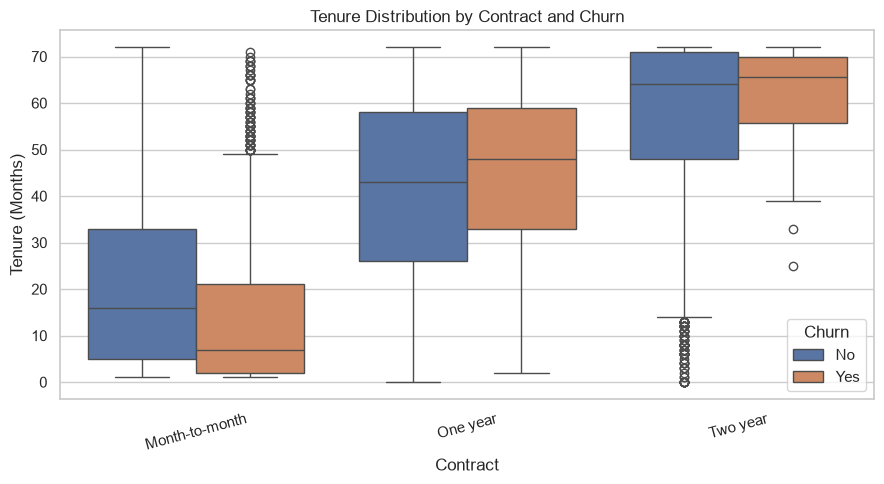

In [44]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Contract",
    y="tenure",
    hue="Churn"
)

plt.title("Tenure Distribution by Contract and Churn")
plt.xlabel("Contract")
plt.ylabel("Tenure (Months)")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "../reports/figures/Tenure Distribution by Contract and Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

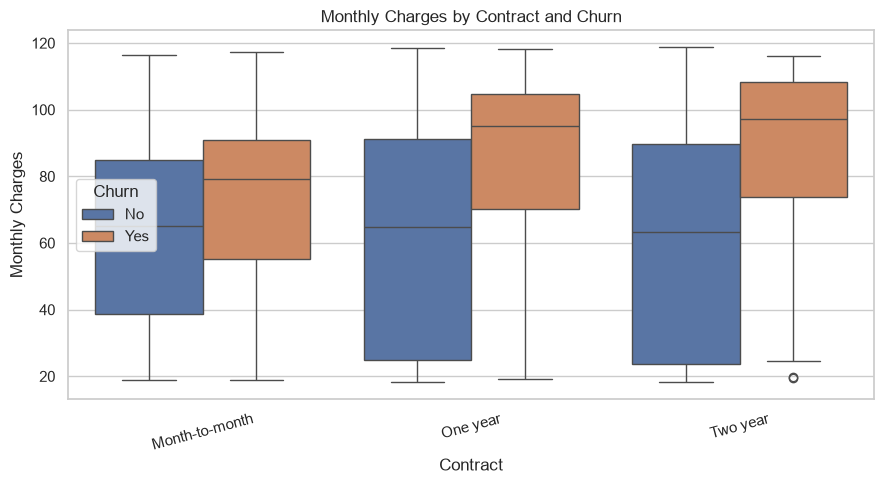

In [45]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Contract",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Monthly Charges by Contract and Churn")
plt.xlabel("Contract")
plt.ylabel("Monthly Charges")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "../reports/figures/Monthly Charges by Contract and Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=[
        "0-6",
        "7-12",
        "13-24",
        "25-48",
        "49-72"
    ],
    include_lowest=True
)

In [47]:
tenure_churn = (
    df.groupby("tenure_group", observed=False)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_churn

tenure_group
0-6      52.937205
7-12     35.886525
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn, dtype: float64

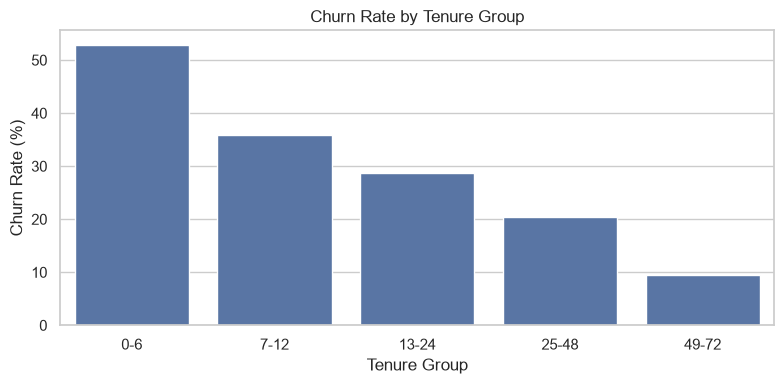

In [48]:
plt.figure(figsize=(8, 4))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Churn Rate by Tenure Group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
contract_internet_churn = pd.crosstab(
    [df["Contract"], df["InternetService"]],
    df["Churn"],
    normalize="index"
) * 100

contract_internet_churn

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699

In [50]:
contract_internet_churn["Yes"].sort_values(
    ascending=False
)

Contract        InternetService
Month-to-month  Fiber optic        54.605263
                DSL                32.215863
One year        Fiber optic        19.294991
Month-to-month  No                 18.893130
One year        DSL                 9.298246
Two year        Fiber optic         7.226107
One year        No                  2.472527
Two year        DSL                 1.910828
                No                  0.783699
Name: Yes, dtype: float64

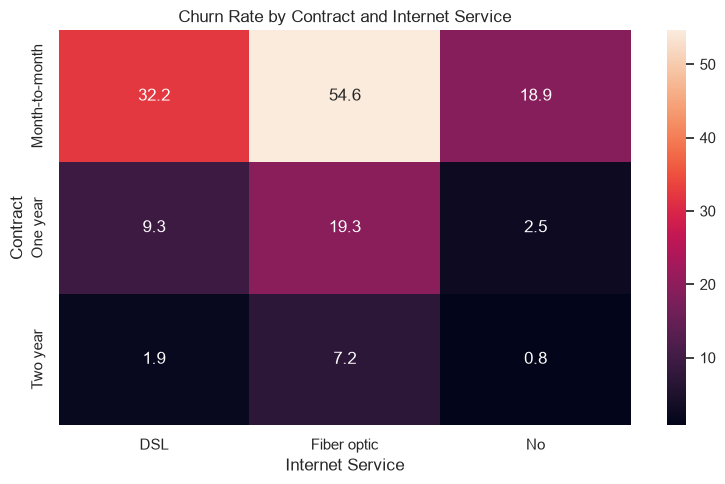

In [52]:
heatmap_data = (
    df.assign(
        churn_binary=(df["Churn"] == "Yes").astype(int)
    )
    .pivot_table(
        index="Contract",
        columns="InternetService",
        values="churn_binary",
        aggfunc="mean"
    )
    * 100
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Contract")

plt.tight_layout()

plt.savefig(
     "../reports/figures/Churn Rate by Contract and Internet Service.png",
        dpi=300,
        bbox_inches="tight"
)

plt.show()

# EDA Summary & Final Conclusions

## 1. Final View of the Data

<div dir="rtl">

داده‌ی نهایی این فاز شامل **۷۰۴۳ ردیف** و **۲۰ ستون** (۱۹ ویژگی + برچسب `Churn`) است. نتایج بررسی‌های کیفیت داده:

- هیچ مقدار گمشده‌ای در هیچ ستونی وجود ندارد.
- **۲۲ ردیف کاملاً تکراری** (همه‌ی ستون‌ها شامل `Churn` یکسان) شناسایی شد.
- پس از حذف شناسه‌ی `customerID`، **۳۳ ترکیب تکراری** از ویژگی‌ها یافت شد؛ از این میان **۱۸ گروه** برچسب‌های `Churn` متضاد دارند (مجموعاً **۴۲ ردیف**).
- این گروه‌ها به‌عنوان «اشتباه داده» در نظر گرفته نشدند و همه‌ی ردیف‌ها **حفظ** شدند؛ اما وجود برچسب‌های متضاد برای ترکیب‌های یکسان، نشانه‌ی **نویز در برچسب‌ها** است که در فاز مدل‌سازی در نظر گرفته می‌شود.

</div>

## 2. Class Imbalance & Its Consequences

<div dir="rtl">

توزیع هدف: **No = ۵۱۷۴ (۷۳.۴۶٪)** و **Yes = ۱۸۶۹ (۲۶.۵۴٪)**.

پیامدها برای مدل‌سازی:

- متریک **Accuracy گمراه‌کننده** است (مدل همیشگیِ No حدود ۷۳.۵٪ دقت می‌دهد)؛ ارزیابی باید بر پایه‌ی **Precision، Recall، F1، ROC-AUC و PR-AUC** باشد.
- برای مدیریت عدم‌تعادل می‌توان از **class_weight** و/یا نمونه‌گیری کنترل‌شده استفاده کرد؛ با این احتیاط که به‌خاطر ۱۸ گروهِ تکراری با برچسب متضاد، **SMOTE** نمونه‌های شبه‌تکراری زیاد خواهد ساخت و باید فقط داخل تا آموزش (با اسپلیت استراتیفایه) اعمال شود.
- در مدل‌سازی، Recall روی کلاس `Yes` (مشتریانِ در حال ترک) از منظر حفظ مشتری اهمیت بیشتری دارد.

</div>

## 3. Numerical Features — Main Findings

<div dir="rtl">

**tenure — قوی‌ترین سیگنال عددی (عامل محافظ):**

- میانگین: No = ۳۷.۵۷ ماه (میانه ۳۸) در برابر Yes = ۱۷.۹۸ ماه (میانه ۱۰).
- نرخ churn با گروه‌های tenure **کاهش منطقی** دارد: ۰–۶ ماه: **۵۲.۹٪**، ۷–۱۲: ۳۵.۹٪، ۱۳–۲۴: ۲۸.۷٪، ۲۵–۴۸: ۲۰.۴٪، ۴۹–۷۲: **۹.۵٪**.
- یعنی **۶ ماه اولِ اشتراک پرریسک‌ترین دوره** است و ریسک با افزایش وفاداری تدریجاً کم می‌شود.

**MonthlyCharges — عامل ریسک:**

- میانگین مشتریان churn (۷۴.۴۴) حدود **۲۱٪ بالاتر** از مشتریان حفظ‌شده (۶۱.۲۷) است.
- مشتریان با هزینه‌ی ماهانه‌ی بالاتر، احتمال ترک بیشتری دارند — به‌ویژه اگر با tenure کوتاه همراه باشد (نمایان‌شده در اسکرپلوت Tenure vs Monthly Charges).

**TotalCharges — بیشتر «نتیجه» است تا «علت مستقل»:**

- مشتریان churn هزینه‌ی کل کمتری دارند (میانگین ۱۵۳۱.۸۰ در برابر ۲۵۴۹.۹۱؛ میانه ۷۰۳.۵۵ در برابر ۱۶۷۹.۵۲) — که عیناً عکسِ tenure کوتاه است.
- همبستگی tenure با TotalCharges برابر **۰.۸۳** و MonthlyCharges با آن **۰.۶۵** است؛ بنابراین TotalCharges در عمل تقریباً حاصل‌ضرب «tenure × هزینه‌ی ماهانه» است.
- توصیه: در مدل‌های چنی (درختی) بی‌آزار است، اما در مدل‌های خطی/منطقی بهتر است حذف شود یا به‌جای آن نسبت **میانگین هزینه‌ی ماهانه** (`TotalCharges / tenure`) به‌عنوان ویژگی مهندسی‌شده استفاده شود.

</div>

## 4. Categorical Features — Ranked by Churn Rate

<div dir="rtl">

ترتیب زیر بر اساس **تفاوت نرخ churn** بین گروه‌های هر ویژگی است:

| ویژگی | پرریسک‌ترین گروه | نرخ | کم‌ریسک‌ترین گروه | نرخ |
|---|---|---|---|---|
| `Contract` | Month-to-month | **42.7%** | Two year | **2.8%** |
| `InternetService` | Fiber optic | 41.9% | No | 7.4% |
| `SeniorCitizen` | Yes | 41.7% | No | 23.6% |
| `OnlineSecurity` | No | 41.8% | Yes | 14.6% |
| `TechSupport` | No | 41.6% | Yes | 15.2% |
| `PaperlessBilling` | Yes | 33.6% | No | 16.3% |
| `Partner` | No | 33.0% | Yes | 19.7% |
| `Dependents` | No | 31.3% | Yes | 15.5% |
| `PaymentMethod` | Electronic check | 45.3% | Credit card (automatic) | 15.2% |
| `StreamingTV` / `StreamingMovies` / `MultipleLines` | اختلاف اندک | ≈ 30% | — | — |
| `gender` | تقریباً بدون اثر | 26.9% / 26.2% | — | — |

</div>

<div dir="rtl">

- **نوع قرارداد** قوی‌ترین ویژگی دسته‌ای است: مشتریِ ماه‌به‌ماه ۱۵ برابرِ مشتریِ قراردادیِ دوساله در معرض churn است.
- **نبود سرویس‌های تکمیلی** (امنیت، پشتیبانی، بکاپ، محافظت از دستگاه) همبستگی قوی با ترک دارد؛ به‌نظر می‌رسد این سرویس‌ها «قفل خدماتی» ایجاد می‌کنند که نبودشان احتمال ترک را دو تا سه برابر می‌کند.
- **مشتریان بدون پیوند** (بدون همسر/وابسته، مسن، بیل کاغذی‌دار، پرداخت با چک الکترونیک) ریسک بالاتری دارند.
- **gender** و سرویس‌های **Streaming** رابطه‌ی معناداری با churn ندارند و می‌توانند در انتخاب ویژگی حذف شوند.

</div>

## 5. Interaction Effects

<div dir="rtl">

**Contract × InternetService** (نرم‌افزار حرارتی):

- پرریسک‌ترین سلول: **Month-to-month + Fiber optic = ۵۴.۶٪**
- کم‌ریسک‌ترین سلول: **Two year + No internet = ۰.۸٪**
- نوع قرارداد عامل غالب است و فایبراپتیک ریسک را در مشتریان ماه‌به‌ماه **تشدید** می‌کند (۵۴.۶٪ در برابر ۳۲.۲٪ برای DSL)؛ اما در قراردادهای یک/دوساله این اثر بسیار کوچک‌تر است (۱۹.۳ در برابر ۹.۳ و ۷.۲ در برابر ۱.۹).
- تفسیر عملی: فایبراپتیک احتمالاً با بسته‌های پرهزینه‌تر و عدم‌رضایت بیشتر همراه است، اما قرارداد بلندمدت این ریسک را خنثی می‌کند.

**Tenure × MonthlyCharges** (اسکرپلوت):

- خوشه‌ی مشخصی از مشتریان churn در ناحیه‌ی **«tenure کوتاه + هزینه‌ی ماهانه‌ی بالا»** دیده می‌شود؛ یعنی مشتریانی که تازه اشتراک گرفته‌اند و مبالغ بالایی می‌پردازند، در خطرناک‌ترین ناحیه قرار دارند.

</div>

## 6. Key Figures of This Phase

<div dir="rtl">

- `churn_distribution.png` — عدم‌تعادل کلاس‌ها
- `Distribution of Customer Tenure.png` — توزیع کشیده‌ی tenure
- `Tenure vs Churn.png` / `Churn Rate by Tenure Group.png` — روند کاهشی ریسک با طول اشتراک
- `Monthly Charges vs Churn.png` — هزینه‌ی ماهانه‌ی بالاتر در churners
- `Total Charges vs Churn.png` — هزینه‌ی کل پایین‌تر در churners (همراه با `Correlation Matrix of Numerical Features.png` برای نشان‌دهی همبستگی ۰.۸۳)
- `Churn Rate by Contract Type.png` — برتری压倒یِ قرارداد بلندمدت
- `Churn Rate by Contract and Internet Service.png` — خطرناک‌ترین و امن‌ترین سلول‌ها
- `Tenure Distribution by Contract and Churn.png` / `Monthly Charges by Contract and Churn.png` — تأثیر متقابل قرارداد

</div>

## 7. Overall Conclusions

<div dir="rtl">

1. **نوع قرارداد** مهم‌ترین عامل تفسیرپذیرِ churn است (۲.۸٪ در برابر ۴۲.۷٪) — بیشترین اثر در کاهش نرخ ترک، تمدید/تغییر قرارداد است.
2. **tenure** مهم‌ترین ویژگی عددی است؛ ریسک به‌صورت منطقی با افزایش آن کاهش می‌یابد و ۶ ماه اول دوره‌ی بحرانی است.
3. **ترکیب «قرارداد ماه‌به‌ماه + فایبراپتیک»** بزرگ‌ترین گروه پرخطر است (۵۴.۶٪) — این مشتریان هم پرمصرف و هم پرریسک‌اند و کاندیدای اصلی برنامه‌های حفظ مشتری‌اند.
4. **نبود سرویس‌های تکمیلی** (OnlineSecurity، TechSupport، OnlineBackup، DeviceProtection) همبستگی قوی با ترک دارد و می‌تواند هم به‌عنوان ویژگی و هم به‌عنوان اهرم بازاریابی استفاده شود.
5. **هزینه‌ی ماهانه‌ی بالا + tenure کوتاه** ناحیه‌ی خطر است؛ TotalCharges به‌تنهایی عامل مستقل نیست و تقریباً با tenure×ماهانه توضیح داده می‌شود.
6. ویژگی‌های **gender و Streaming** عملاً بی‌اثرند.
7. داده دارای **عدم‌تعادل کلاس** و مقدار کمی **نویز برچسب** (۴۲ ردیف) است که هر دو باید در فاز مدل‌سازی مدیریت شوند.

</div>
